### __Import Libraries and Data__

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [7]:
file_path = "/mnt/Docs/Git_Repo/Credit_Scorecard/Data/raw/loan_data.csv"

if os.path.exists(file_path):
    try:
        data = pd.read_csv(file_path)
        print("Data loaded successfully.")
    except Exception as e:
        print(f"Error: An error occurred while loading the data: {e}")
else:
    print(f"Error: The file at {file_path} was not found. Please check the path and try again.")

data.shape

Data loaded successfully.


(45000, 13)

**Let's change the name of some variables for better explainability**

In [8]:
data.rename(columns={"person_age":"age","person_gender":"gender","person_education":"education_level","person_income":"income","person_emp_exp":"work_experience",
                    "person_home_ownership":"home_ownership_status","loan_percent_income":'loan_to_income_ratio',"cb_person_cred_hist_length":"credit_history_length"},
           inplace=True)

### __Exploratory Data Analysis__

In [9]:
# Let's check the column names
data.columns

Index(['age', 'gender', 'education_level', 'income', 'work_experience',
       'home_ownership_status', 'loan_amnt', 'loan_intent', 'loan_int_rate',
       'loan_to_income_ratio', 'credit_history_length',
       'previous_loan_defaults_on_file', 'loan_status'],
      dtype='str')

In [10]:
""" 
Here, the objective is to develop a credit scorecard model that will convert probability of default into a score between 300 and 1000. 

We will exclude loan amount and interest rate from the risk indicators because they are terms of the loan not variables to evaluate credit worthiness of the borrower. 

""" 
loan_data = data.drop(columns=["loan_amnt", "loan_int_rate"])

In [11]:
# Ratio of approved vs rejected loans; "Loan Status" : 1 = approved; 0 = rejected
loan_data['loan_status'].value_counts(normalize=True)

loan_status
0    0.777778
1    0.222222
Name: proportion, dtype: float64

In [12]:
# Missing Values 
loan_data.isna().sum()

age                               0
gender                            0
education_level                   0
income                            0
work_experience                   0
home_ownership_status             0
loan_intent                       0
loan_to_income_ratio              0
credit_history_length             0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

**So there is no missing values**

### __Numerical Variables__

In [13]:
# Simple Statistics of the Numerical Columns
num_cols = loan_data.drop(columns=["loan_status"]).select_dtypes(include=np.number).columns.to_list()
print(loan_data[num_cols].describe())

                age        income  work_experience  loan_to_income_ratio  \
count  45000.000000  4.500000e+04     45000.000000          45000.000000   
mean      27.764178  8.031905e+04         5.410333              0.139725   
std        6.045108  8.042250e+04         6.063532              0.087212   
min       20.000000  8.000000e+03         0.000000              0.000000   
25%       24.000000  4.720400e+04         1.000000              0.070000   
50%       26.000000  6.704800e+04         4.000000              0.120000   
75%       30.000000  9.578925e+04         8.000000              0.190000   
max      144.000000  7.200766e+06       125.000000              0.660000   

       credit_history_length  
count           45000.000000  
mean                5.867489  
std                 3.879702  
min                 2.000000  
25%                 3.000000  
50%                 4.000000  
75%                 8.000000  
max                30.000000  


**The simple describe function shows some basic statistics regarding the variables. <br>
The max value of age and work experience indicates that there are outliers in those variables.**

#### __Detect Outliers__

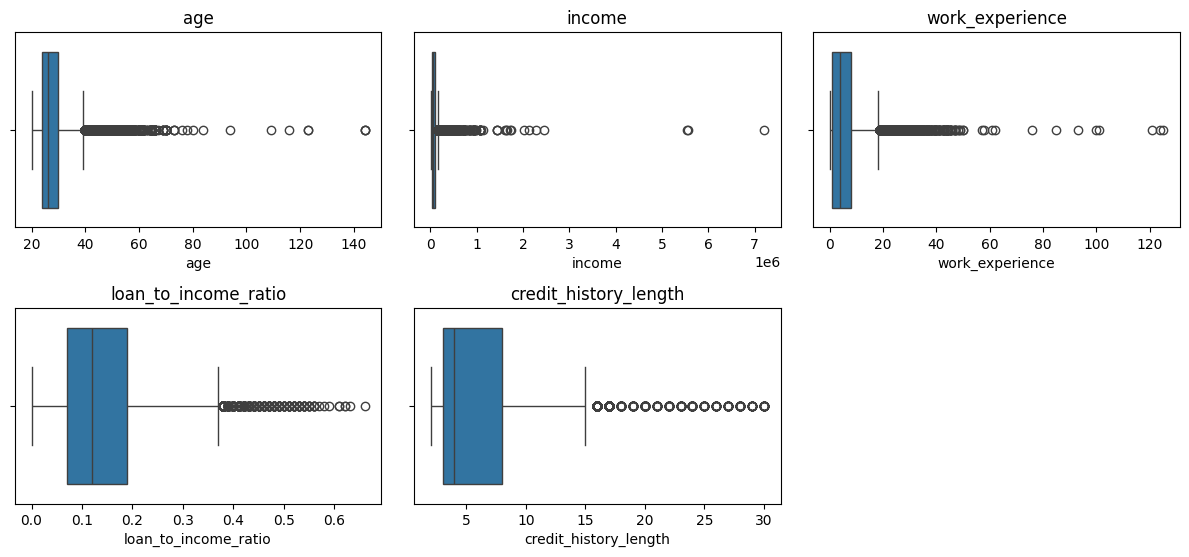

In [14]:
fig, axes = plt.subplots(ncols=3, nrows=3, figsize=(12, 8)) 
fig.tight_layout(pad=4.0) 

axes = axes.flatten() 

for i, col in enumerate(num_cols): 
    sns.boxplot(x=loan_data[col], ax=axes[i])
    axes[i].set_title(f"{col}")

# Removing the ghost plot 
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**There are some extreme outliers in the age, and employment experience.**

In [15]:
"""
Dropping the outliers. 
""" 
loan_data = loan_data.drop(index=loan_data.loc[loan_data['age'] > 90].index)
loan_data = loan_data.drop(index=loan_data.loc[loan_data['work_experience'] > 40].index)
loan_data.shape

(44935, 11)

#### __Distribution of the Numerical Variables__

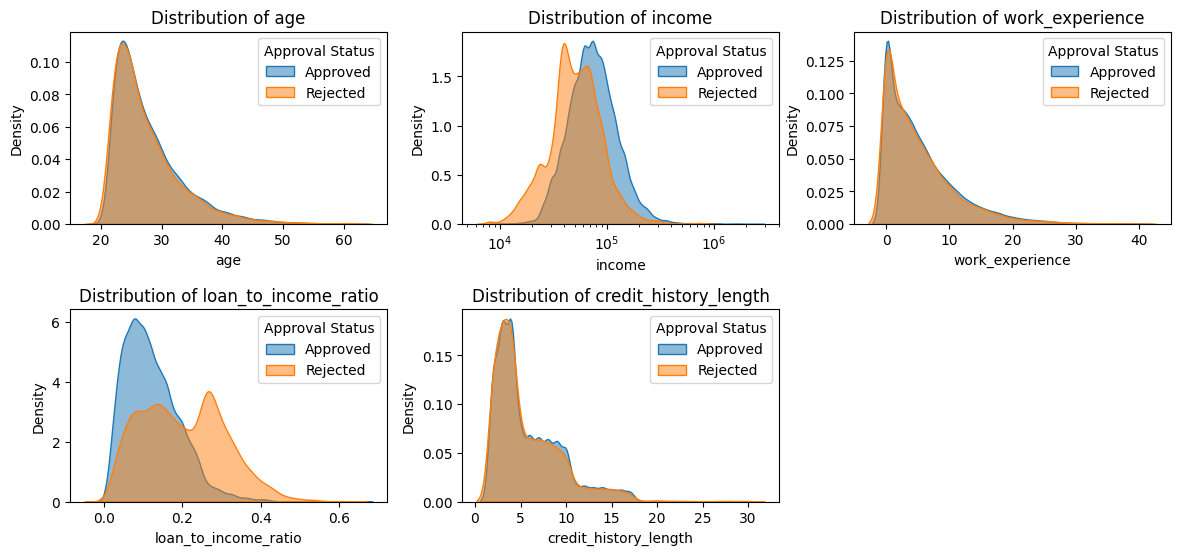

In [16]:
fig, axes = plt.subplots(ncols=3, nrows=3, figsize=(12, 8)) 
fig.tight_layout(pad=4.0) 

axes = axes.flatten() 

for i, col in enumerate(num_cols): 
    if col == "income": 
        sns.kdeplot(data=loan_data.loc[loan_data['loan_status'] == 0], x=col, fill=True,  common_norm=False, 
               alpha=0.5, log_scale=True, ax=axes[i])
        sns.kdeplot(data=loan_data.loc[loan_data['loan_status'] == 1], x=col, fill=True,  common_norm=False, 
               alpha=0.5, log_scale=True, ax=axes[i])
    else: 
        sns.kdeplot(data=loan_data.loc[loan_data['loan_status'] == 0], x=col, fill=True, common_norm=False, 
                    alpha=0.5,ax=axes[i]) 
        sns.kdeplot(data=loan_data.loc[loan_data['loan_status'] == 1], x=col, fill=True, common_norm=False, 
                    alpha=0.5,ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density") 
    axes[i].legend(title = "Approval Status", labels = ['Approved',"Rejected"])

# Removing the ghost plot 
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- **Distribution of age, work experience and credit hitory length is almost similar for both approved and rejected borrowers.**
- **The distribution plot of income indicated that income of approved borrowers are slightly higher than rejected borrowers.** 
- **Distribution plot of loan to income ratio indicated that approved borrowers have lower loan to income ratio than rejected borrowers. This is intuitively correct because borrowers whose repayment obligations are significantly lower than their income are more likely to get approval.**

In [17]:
# Let's check their degree of skewness 
for col in num_cols: 
    skewness = loan_data[col].skew()  
    print(f"{col}: {round(skewness,2)}")

age: 1.66
income: 9.26
work_experience: 1.69
loan_to_income_ratio: 1.03
credit_history_length: 1.57


**All variables are positively skewed. Income is the most extreme case, which is typical since income distributions are naturally pyramid-shaped, with very few people earning exceptionally high amounts.**

#### __Correlation Matrix__

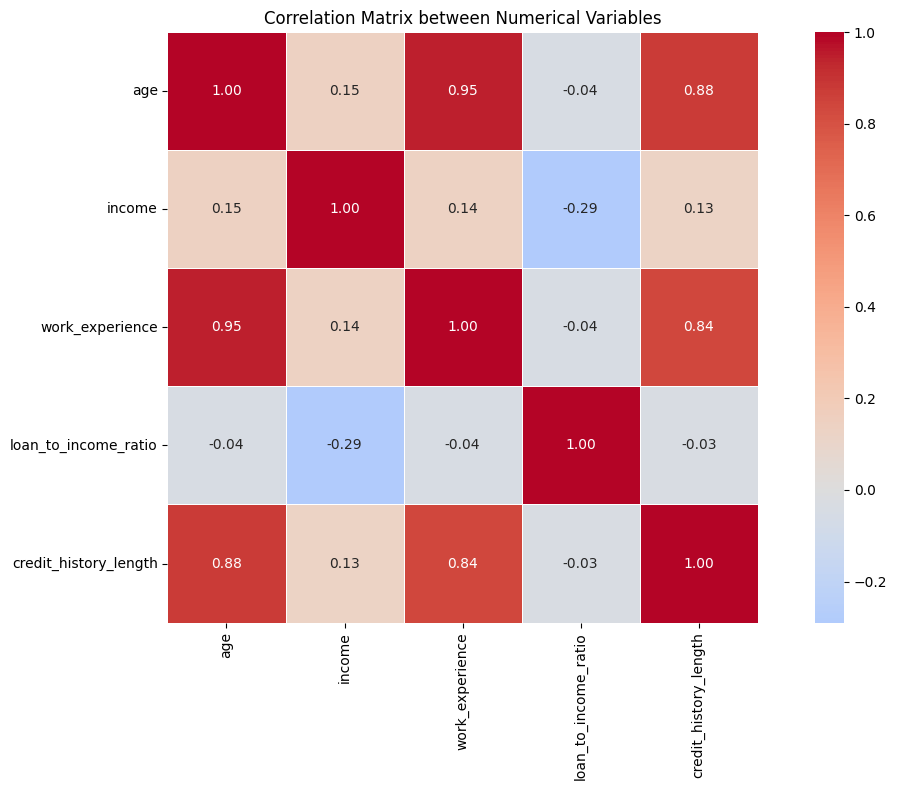

In [18]:
def heatmap_correlation(data, num_cols):
    corr = data[num_cols].corr() 
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
    plt.title("Correlation Matrix between Numerical Variables")
    plt.tight_layout()
    plt.show() 
    return corr

correlation_matrix = heatmap_correlation(loan_data[num_cols], num_cols)

**It's only natural age, work experience and credit history length are correlated because with age both work experience and credit history increases. <br> 
This relationship is likely to result multi-collinearity, which we will investigate in down the line when calculating information value.**

#### **Multi-variate Analysis**

In [24]:
plot_data = loan_data.copy()
cat_cols = plot_data.select_dtypes(exclude=[int,float]).columns.to_list()
plot_data = plot_data.drop(columns=cat_cols)
plot_data['loan_status'] = plot_data['loan_status'].map({0:"Rejected",1:"Approved"})
plot_data.info()

<class 'pandas.DataFrame'>
Index: 44935 entries, 0 to 44999
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    44935 non-null  int64  
 1   income                 44935 non-null  int64  
 2   work_experience        44935 non-null  int64  
 3   loan_to_income_ratio   44935 non-null  float64
 4   credit_history_length  44935 non-null  int64  
 5   loan_status            44935 non-null  str    
dtypes: float64(1), int64(4), str(1)
memory usage: 2.4 MB


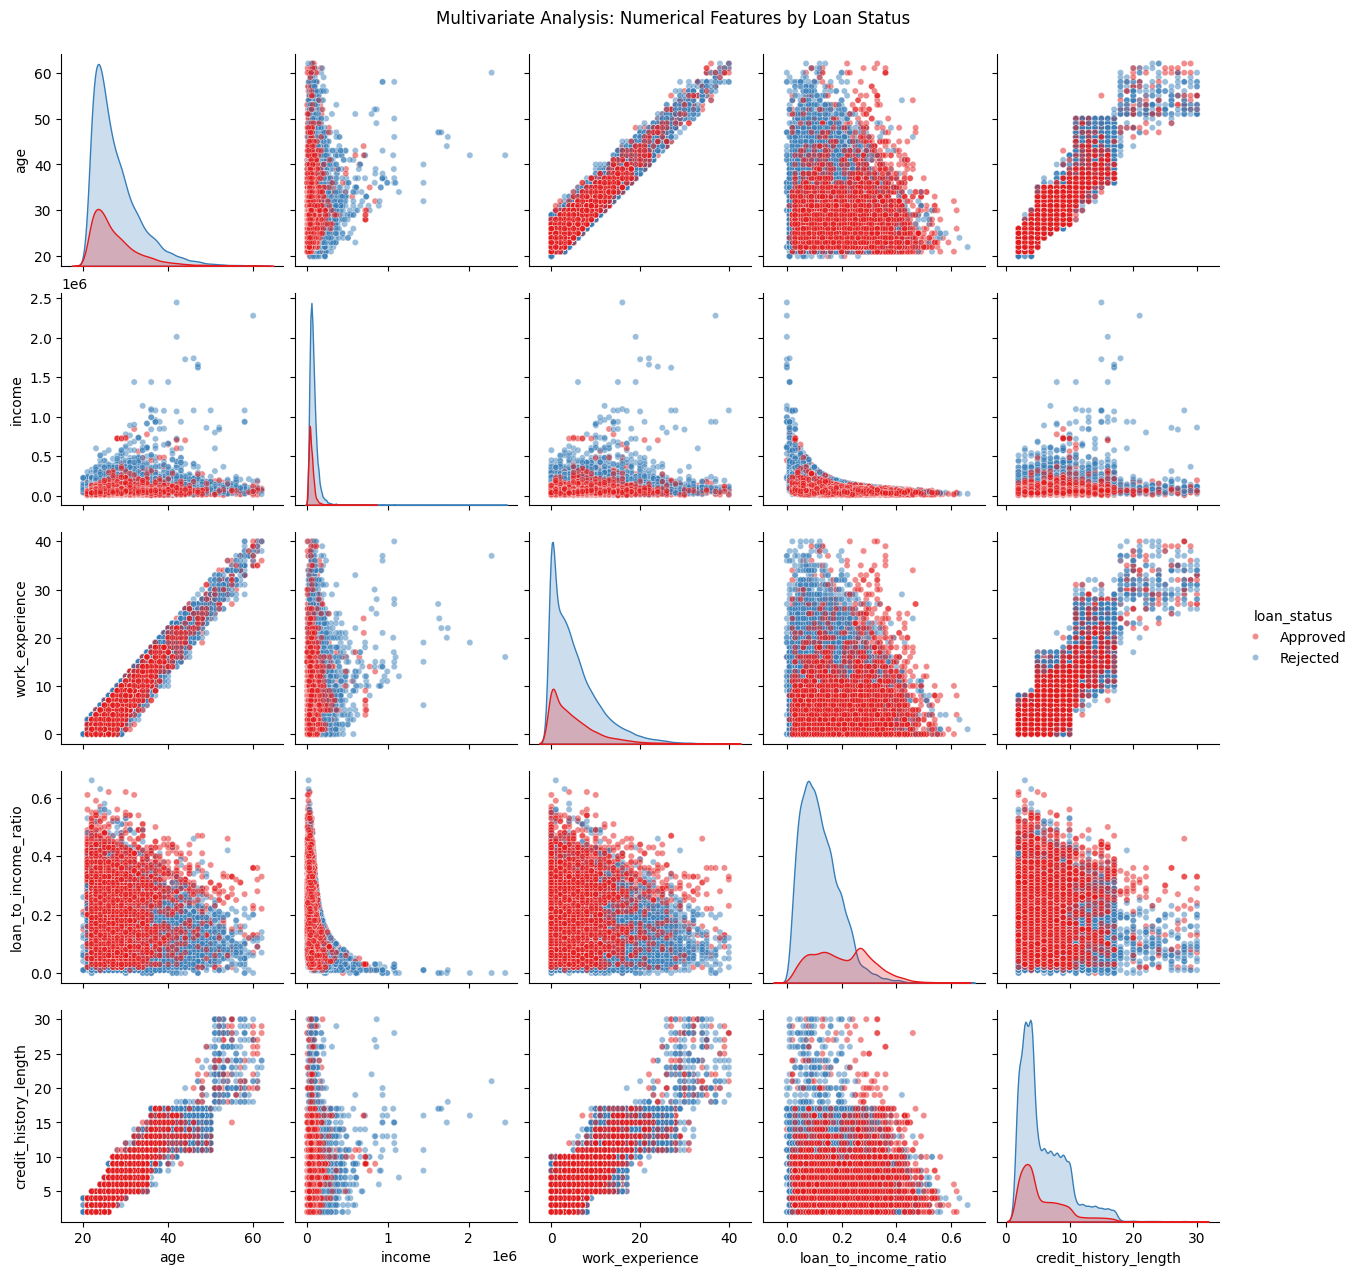

In [25]:
pair_plot = sns.pairplot(
    plot_data,
    hue='loan_status', 
    palette='Set1', 
    diag_kind='kde',  # Shows the distribution on the diagonal
    plot_kws={'alpha': 0.5, 's': 20} # Transparency and size of dots
)

# 3. Add a title and adjust layout
pair_plot.fig.suptitle("Multivariate Analysis: Numerical Features by Loan Status", y = 1.02)
plt.show()

#### __Pair Plot Analysis__
- **The pairplot of age and income indicates that income tends to increase until the age of 40 or little over 40, after which it stabilizes or declines. Conversely, most approved loans are concentrated among young adults in the lower income bracket.**
- **As observed earlier, age, employment length and credit history length are correlated with each other.**
- **Pairplot between age and credit score indicated that older adults are more likely to have higher credit score.**
- **Like age, credit score is also higher for applicants with longer credit history.**
- **The pairplot of income versus credit score indicates that applicants with higher credit scores but lower income levels received a higher volume of approvals.**

### __Categorical Variables__

In [26]:
cat_cols = loan_data.drop(columns=["loan_status"]).select_dtypes(exclude=[np.number]).columns.to_list() 
print(cat_cols)

['gender', 'education_level', 'home_ownership_status', 'loan_intent', 'previous_loan_defaults_on_file']


In [27]:
loan_data_temp = loan_data.copy()
loan_data_temp['loan_status'] = loan_data_temp['loan_status'].map({0:"Rejected",1:"Approved"})

In [28]:
loan_data_temp['loan_status'].value_counts()

loan_status
Rejected    34946
Approved     9989
Name: count, dtype: int64

In [29]:
from scipy.stats import chi2_contingency

# List to store results
results = []

for col in cat_cols:
    # contingency table
    contingency_table = pd.crosstab(loan_data_temp['loan_status'],loan_data_temp[col])
    
    # Chi-square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    # Store results in a dictionary
    results.append({
        'Variable': col,
        'Chi-Square': round(chi2, 4),
        'P-Value': round(p, 5),
        'Significant': 'Yes' if p < 0.05 else 'No'
    })

# Convert to DataFrame for easy viewing
results_df = pd.DataFrame(results).sort_values(by='P-Value')
print(results_df)

                         Variable  Chi-Square  P-Value Significant
3                     loan_intent    905.9715  0.00000         Yes
2           home_ownership_status   2987.4448  0.00000         Yes
4  previous_loan_defaults_on_file  13274.7344  0.00000         Yes
1                 education_level      2.0820  0.72068          No
0                          gender      0.0022  0.96239          No


- **Education and gender have very low Chi-square stat and high p-value, means that the observed frequencies are almost similar in both approved and rejected loan applications.**
- **Before discarding these variables, we will analyze the Weight of evidence (WOE) and information value (IV) to confirm the significance of education and gender.**

In [30]:
loan_data.to_csv("/mnt/Docs/Git_Repo/Credit_Scorecard/Data/interim/loan_data_processed.csv",index=False)